# 🛒 Association Rules (Apriori) — Market Basket Analysis

Every prior Unsupervised topic worked with continuous numerical features and distance or density. Association rule mining works with something structurally different: sets of discrete items, and the question isn't "how far apart are these points" but "which items tend to appear together." This is the final topic in the Classical ML series -- Apriori's core insight (the downward-closure property) is what makes searching an otherwise combinatorially explosive space of itemsets tractable, and this notebook builds it from scratch, verifies it against `mlxtend`, and is explicit about a real, common trap: confidence alone can be a misleading measure of association.

📖 Full mathematical explanation (support/confidence/lift derivations, the Apriori downward-closure proof, FP-Growth comparison): [README.md](README.md)


## 1. Setup & Datasets

A tiny, hand-traceable set of grocery transactions (small enough to verify every step by hand) plus a larger synthetic transactional dataset (1000 transactions, 20 items, with deliberately embedded strong and weak associations) for a realistic-scale application.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from itertools import combinations
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

sns.set_theme(style="whitegrid")
np.random.seed(42)


In [2]:
tiny_transactions = [
    ["bread", "milk"],
    ["bread", "diaper", "beer", "eggs"],
    ["milk", "diaper", "beer", "cola"],
    ["bread", "milk", "diaper", "beer"],
    ["bread", "milk", "diaper", "cola"],
    ["milk", "diaper", "beer"],
    ["bread", "milk", "diaper", "beer", "eggs"],
    ["bread", "milk", "cola"],
    ["diaper", "beer"],
    ["bread", "diaper", "beer"],
]
print(f"Tiny dataset: {len(tiny_transactions)} transactions, {len(set(item for t in tiny_transactions for item in t))} unique items")
for i, t in enumerate(tiny_transactions):
    print(f"  transaction {i}: {t}")


Tiny dataset: 10 transactions, 6 unique items
  transaction 0: ['bread', 'milk']
  transaction 1: ['bread', 'diaper', 'beer', 'eggs']
  transaction 2: ['milk', 'diaper', 'beer', 'cola']
  transaction 3: ['bread', 'milk', 'diaper', 'beer']
  transaction 4: ['bread', 'milk', 'diaper', 'cola']
  transaction 5: ['milk', 'diaper', 'beer']
  transaction 6: ['bread', 'milk', 'diaper', 'beer', 'eggs']
  transaction 7: ['bread', 'milk', 'cola']
  transaction 8: ['diaper', 'beer']
  transaction 9: ['bread', 'diaper', 'beer']


In [3]:
items_pool = [f"item_{i}" for i in range(20)]
rng = np.random.RandomState(1)
large_transactions = []
for _ in range(1000):
    basket = set(str(x) for x in rng.choice(items_pool, size=rng.randint(2, 6), replace=False))
    if rng.random() < 0.4:
        basket.update(["item_0", "item_1"])
    if rng.random() < 0.15:
        basket.update(["item_5", "item_6"])
    large_transactions.append(list(basket))
print(f"Large dataset generated: {len(large_transactions)} transactions.")


Large dataset generated: 1000 transactions.


In [4]:
print(f"Large dataset: {len(large_transactions)} transactions, {len(items_pool)} possible items")
print(f"'item_0' and 'item_1' were deliberately co-inserted together ~40% of the time -- a designed STRONG association.")
print(f"'item_5' and 'item_6' were deliberately co-inserted together ~15% of the time -- a designed WEAKER association.")


Large dataset: 1000 transactions, 20 possible items
'item_0' and 'item_1' were deliberately co-inserted together ~40% of the time -- a designed STRONG association.
'item_5' and 'item_6' were deliberately co-inserted together ~15% of the time -- a designed WEAKER association.


## 2. One-Hot Encoding Transactions

Apriori works on a boolean matrix: one row per transaction, one column per item, `True` if that item appears in that transaction. `TransactionEncoder` performs exactly this transformation.


In [5]:
te = TransactionEncoder()
te_array = te.fit(tiny_transactions).transform(tiny_transactions)
tiny_df = pd.DataFrame(te_array, columns=te.columns_)
tiny_df


,beer,bread,cola,diaper,eggs,milk
0,False,True,False,False,False,True
1,True,True,False,True,True,False
2,True,False,True,True,False,True
3,True,True,False,True,False,True
4,False,True,True,True,False,True
5,True,False,False,True,False,True
6,True,True,False,True,True,True
7,False,True,True,False,False,True
8,True,False,False,True,False,False
9,True,True,False,True,False,False


## 3. Support — How Often an Itemset Appears

$$\text{support}(X) = \frac{|\{t \in T : X \subseteq t\}|}{|T|}$$

The fraction of all transactions containing itemset $X$. It's the same idea as a marginal probability, computed empirically.


In [6]:
def manual_support(df, itemset):
    mask = df[list(itemset)].all(axis=1)
    return mask.sum() / len(df)

single_item_supports = {item: manual_support(tiny_df, [item]) for item in tiny_df.columns}
print("Support of each single item:")
for item, supp in sorted(single_item_supports.items(), key=lambda x: -x[1]):
    print(f"  {item:<8}: {supp:.2f}")


Support of each single item:
  diaper  : 0.80
  beer    : 0.70
  bread   : 0.70
  milk    : 0.70
  cola    : 0.30
  eggs    : 0.20


In [7]:
pair_support = manual_support(tiny_df, ["diaper", "beer"])
print(f"support({{diaper, beer}}) = {pair_support:.2f}")

sklearn_apriori_check = apriori(tiny_df, min_support=0.01, use_colnames=True)
mlxtend_pair_support = sklearn_apriori_check[sklearn_apriori_check["itemsets"] == frozenset({"diaper", "beer"})]["support"].iloc[0]
print(f"mlxtend's apriori() support for the same itemset: {mlxtend_pair_support:.2f}")
print(f"Match? {np.isclose(pair_support, mlxtend_pair_support)}")


support({diaper, beer}) = 0.70
mlxtend's apriori() support for the same itemset: 0.70
Match? True


## 4. The Apriori Principle — Why This Search Is Tractable at All

With 8 items, there are $2^8 - 1 = 255$ possible non-empty itemsets to check -- and this grows exponentially with item count. The Apriori (downward-closure) principle makes an exhaustive search unnecessary: **if an itemset is infrequent, every superset of it must also be infrequent** (adding more required items can only keep support the same or make it drop). This means once an itemset fails the minimum support threshold, every itemset built on top of it can be skipped without checking.


In [8]:
min_support_demo = 0.3
infrequent_pair = None
for item_a, item_b in combinations(tiny_df.columns, 2):
    supp = manual_support(tiny_df, [item_a, item_b])
    if supp < min_support_demo:
        infrequent_pair = (item_a, item_b)
        break

print(f"Found an infrequent pair: {infrequent_pair}, support={manual_support(tiny_df, list(infrequent_pair)):.2f} < {min_support_demo}")

superset_items = [c for c in tiny_df.columns if c not in infrequent_pair]
superset_support = manual_support(tiny_df, list(infrequent_pair) + [superset_items[0]])
print(f"Any 3-item superset containing this pair, e.g. {set(infrequent_pair) | {superset_items[0]}}: support={superset_support:.2f}")
print(f"-> The superset's support ({superset_support:.2f}) is <= the pair's support ({manual_support(tiny_df, list(infrequent_pair)):.2f}), confirming downward closure -- this superset (and every other superset of this pair) can be pruned WITHOUT even computing its support.")


Found an infrequent pair: ('beer', 'cola'), support=0.10 < 0.3
Any 3-item superset containing this pair, e.g. {'bread', 'beer', 'cola'}: support=0.00
-> The superset's support (0.00) is <= the pair's support (0.10), confirming downward closure -- this superset (and every other superset of this pair) can be pruned WITHOUT even computing its support.


## 5. Apriori From Scratch

Level-by-level frequent itemset generation: find frequent 1-itemsets, use them to build only *candidate* 2-itemsets (pairs of frequent 1-itemsets), filter to frequent 2-itemsets, repeat for 3-itemsets, and so on -- pruning at every level using the downward-closure principle from Section 4.


In [9]:
def apriori_from_scratch(df, min_support):
    n = len(df)
    frequent_itemsets = {}

    candidates_1 = [frozenset([item]) for item in df.columns]
    current_frequent = []
    for c in candidates_1:
        supp = manual_support(df, list(c))
        if supp >= min_support:
            current_frequent.append(c)
            frequent_itemsets[c] = supp

    k = 2
    while current_frequent:
        candidates_k = set()
        for i in range(len(current_frequent)):
            for j in range(i + 1, len(current_frequent)):
                union = current_frequent[i] | current_frequent[j]
                if len(union) == k:
                    candidates_k.add(union)

        next_frequent = []
        for candidate in candidates_k:
            subsets = [frozenset(s) for s in combinations(candidate, k - 1)]
            if all(s in frequent_itemsets for s in subsets):
                supp = manual_support(df, list(candidate))
                if supp >= min_support:
                    next_frequent.append(candidate)
                    frequent_itemsets[candidate] = supp

        current_frequent = next_frequent
        k += 1

    return frequent_itemsets

print("From-scratch Apriori (level-wise candidate generation + downward-closure pruning) defined.")


From-scratch Apriori (level-wise candidate generation + downward-closure pruning) defined.


In [10]:
manual_frequent = apriori_from_scratch(tiny_df, min_support=0.3)
print(f"Manual Apriori found {len(manual_frequent)} frequent itemsets at min_support=0.3:")
for itemset, supp in sorted(manual_frequent.items(), key=lambda x: -x[1]):
    print(f"  {set(itemset)}: support={supp:.2f}")


Manual Apriori found 15 frequent itemsets at min_support=0.3:
  {'diaper'}: support=0.80
  {'beer'}: support=0.70
  {'bread'}: support=0.70
  {'milk'}: support=0.70
  {'diaper', 'beer'}: support=0.70
  {'diaper', 'milk'}: support=0.50
  {'bread', 'milk'}: support=0.50
  {'bread', 'diaper'}: support=0.50
  {'beer', 'milk'}: support=0.40
  {'bread', 'beer'}: support=0.40
  {'diaper', 'beer', 'milk'}: support=0.40
  {'bread', 'diaper', 'beer'}: support=0.40
  {'cola'}: support=0.30
  {'cola', 'milk'}: support=0.30
  {'bread', 'diaper', 'milk'}: support=0.30


In [11]:
mlxtend_frequent = apriori(tiny_df, min_support=0.3, use_colnames=True)
mlxtend_itemsets = set(mlxtend_frequent["itemsets"])
manual_itemsets = set(manual_frequent.keys())

print(f"Manual found {len(manual_itemsets)} itemsets, mlxtend found {len(mlxtend_itemsets)} itemsets")
print(f"Identical sets of itemsets? {manual_itemsets == mlxtend_itemsets}")

supports_match = all(np.isclose(manual_frequent[fs], mlxtend_frequent[mlxtend_frequent["itemsets"] == fs]["support"].iloc[0]) for fs in manual_itemsets)
print(f"All support values match? {supports_match}")


Manual found 15 itemsets, mlxtend found 15 itemsets
Identical sets of itemsets? True
All support values match? True


## 6. Confidence — How Reliable Is a Rule?

$$\text{confidence}(A \Rightarrow B) = \frac{\text{support}(A \cup B)}{\text{support}(A)}$$

Given that $A$ occurred, what fraction of the time did $B$ also occur? This is exactly the conditional probability $P(B \mid A)$, estimated empirically from the transaction data.


In [12]:
def manual_confidence(df, antecedent, consequent):
    return manual_support(df, antecedent + consequent) / manual_support(df, antecedent)

conf_diaper_beer = manual_confidence(tiny_df, ["diaper"], ["beer"])
conf_beer_diaper = manual_confidence(tiny_df, ["beer"], ["diaper"])
print(f"confidence(diaper -> beer) = {conf_diaper_beer:.3f}")
print(f"confidence(beer -> diaper) = {conf_beer_diaper:.3f}")
print(f"-> Confidence is NOT symmetric -- P(beer|diaper) and P(diaper|beer) are generally different numbers, even though support(diaper,beer) is the same either direction.")


confidence(diaper -> beer) = 0.875
confidence(beer -> diaper) = 1.000
-> Confidence is NOT symmetric -- P(beer|diaper) and P(diaper|beer) are generally different numbers, even though support(diaper,beer) is the same either direction.


## 7. Lift — Confidence Alone Can Be Misleading

$$\text{lift}(A \Rightarrow B) = \frac{\text{confidence}(A \Rightarrow B)}{\text{support}(B)} = \frac{\text{support}(A \cup B)}{\text{support}(A) \cdot \text{support}(B)}$$

Lift compares the rule's confidence against $B$'s baseline frequency. Lift $>1$ means $A$ and $B$ appear together more than chance would predict (positive association); lift $=1$ means independence; lift $<1$ means negative association.


In [13]:
def manual_lift(df, antecedent, consequent):
    conf = manual_confidence(df, antecedent, consequent)
    return conf / manual_support(df, consequent)

lift_diaper_beer = manual_lift(tiny_df, ["diaper"], ["beer"])
print(f"lift(diaper -> beer) = {lift_diaper_beer:.3f}")
print(f"-> Lift > 1 means diaper purchases genuinely raise the likelihood of a beer purchase beyond beer's own baseline rate -- not just that both happen to be common items.")


lift(diaper -> beer) = 1.250
-> Lift > 1 means diaper purchases genuinely raise the likelihood of a beer purchase beyond beer's own baseline rate -- not just that both happen to be common items.


In [14]:
rules_check = association_rules(mlxtend_frequent, metric="confidence", min_threshold=0.0, num_itemsets=len(mlxtend_frequent))
mlxtend_rule = rules_check[(rules_check["antecedents"] == frozenset({"diaper"})) & (rules_check["consequents"] == frozenset({"beer"}))]
print(f"Manual: confidence={conf_diaper_beer:.4f}, lift={lift_diaper_beer:.4f}")
print(f"mlxtend: confidence={mlxtend_rule['confidence'].iloc[0]:.4f}, lift={mlxtend_rule['lift'].iloc[0]:.4f}")
print(f"Match? {np.isclose(conf_diaper_beer, mlxtend_rule['confidence'].iloc[0]) and np.isclose(lift_diaper_beer, mlxtend_rule['lift'].iloc[0])}")


Manual: confidence=0.8750, lift=1.2500
mlxtend: confidence=0.8750, lift=1.2500
Match? True


### Generating Every Candidate Rule From the Frequent Itemsets

Every frequent itemset of size >= 2 can be split into an antecedent and consequent in multiple ways -- e.g. `{bread, diaper, beer}` can become `bread -> {diaper, beer}`, `{bread, diaper} -> beer`, `diaper -> {bread, beer}`, and so on. Generating all such splits, not just one example pair, is the complete rule-mining process.


In [15]:
def generate_all_rules(frequent_itemsets, df, min_confidence=0.5):
    rules = []
    for itemset, supp in frequent_itemsets.items():
        if len(itemset) < 2:
            continue
        for i in range(1, len(itemset)):
            for antecedent_tuple in combinations(itemset, i):
                antecedent = frozenset(antecedent_tuple)
                consequent = itemset - antecedent
                conf = manual_confidence(df, list(antecedent), list(consequent))
                lift = manual_lift(df, list(antecedent), list(consequent))
                if conf >= min_confidence:
                    rules.append({"antecedent": set(antecedent), "consequent": set(consequent), "confidence": round(conf, 3), "lift": round(lift, 3)})
    return rules

all_manual_rules = generate_all_rules(manual_frequent, tiny_df, min_confidence=0.7)
print(f"Generated {len(all_manual_rules)} rules with confidence >= 0.7 from {len(manual_frequent)} frequent itemsets:")
for r in sorted(all_manual_rules, key=lambda x: -x["lift"])[:8]:
    print(f"  {r['antecedent']} -> {r['consequent']}: confidence={r['confidence']}, lift={r['lift']}")


Generated 11 rules with confidence >= 0.7 from 15 frequent itemsets:
  {'cola'} -> {'milk'}: confidence=1.0, lift=1.429
  {'diaper'} -> {'beer'}: confidence=0.875, lift=1.25
  {'beer'} -> {'diaper'}: confidence=1.0, lift=1.25
  {'beer', 'milk'} -> {'diaper'}: confidence=1.0, lift=1.25
  {'bread', 'beer'} -> {'diaper'}: confidence=1.0, lift=1.25
  {'diaper', 'milk'} -> {'beer'}: confidence=0.8, lift=1.143
  {'bread', 'diaper'} -> {'beer'}: confidence=0.8, lift=1.143
  {'bread'} -> {'milk'}: confidence=0.714, lift=1.02


In [16]:
mlxtend_all_rules = association_rules(mlxtend_frequent, metric="confidence", min_threshold=0.7, num_itemsets=len(mlxtend_frequent))
print(f"Manual rule generation found {len(all_manual_rules)} rules.")
print(f"mlxtend's association_rules found {len(mlxtend_all_rules)} rules.")
print(f"Same count? {len(all_manual_rules) == len(mlxtend_all_rules)}")


Manual rule generation found 11 rules.
mlxtend's association_rules found 11 rules.
Same count? True


## 8. The Trap — High Confidence, But Misleading

A rule can have high confidence purely because the consequent is extremely common, not because of any real relationship. Constructing this trap deliberately rather than just describing it.


In [17]:
trap_transactions = []
rng_trap = np.random.RandomState(2)
for _ in range(200):
    basket = ["milk"] if rng_trap.random() < 0.95 else []
    if rng_trap.random() < 0.1:
        basket.append("saffron")
    if len(basket) == 0:
        basket.append("bread")
    trap_transactions.append(basket)

te_trap = TransactionEncoder()
trap_df = pd.DataFrame(te_trap.fit(trap_transactions).transform(trap_transactions), columns=te_trap.columns_)
print(f"Built a 200-transaction dataset where milk is in 95% of baskets regardless of anything else.")


Built a 200-transaction dataset where milk is in 95% of baskets regardless of anything else.


In [18]:
conf_saffron_milk = manual_confidence(trap_df, ["saffron"], ["milk"])
lift_saffron_milk = manual_lift(trap_df, ["saffron"], ["milk"])
print(f"confidence(saffron -> milk) = {conf_saffron_milk:.3f}  (looks like a strong, reliable rule!)")
print(f"support(milk) = {manual_support(trap_df, ['milk']):.3f}  (milk is in nearly every transaction, regardless of saffron)")
print(f"lift(saffron -> milk) = {lift_saffron_milk:.3f}")
print("-> Confidence alone looked impressive, but lift near 1.0 reveals milk was ALREADY that likely with or without saffron -- there's no real association here, just two independently common/near-universal items. This is exactly why lift, not confidence alone, should drive which rules are considered meaningful.")


confidence(saffron -> milk) = 1.000  (looks like a strong, reliable rule!)
support(milk) = 0.965  (milk is in nearly every transaction, regardless of saffron)
lift(saffron -> milk) = 1.036
-> Confidence alone looked impressive, but lift near 1.0 reveals milk was ALREADY that likely with or without saffron -- there's no real association here, just two independently common/near-universal items. This is exactly why lift, not confidence alone, should drive which rules are considered meaningful.


## 9. The Effect of `min_support` — Combinatorial Growth in Reverse

Lowering `min_support` allows exponentially more itemsets to qualify as frequent -- directly visualizing the combinatorial search space Apriori's pruning has to manage.


In [19]:
te_large = TransactionEncoder()
large_df = pd.DataFrame(te_large.fit(large_transactions).transform(large_transactions), columns=te_large.columns_)

support_sweep = []
for min_supp in [0.5, 0.3, 0.1, 0.05, 0.02, 0.01]:
    frequent = apriori(large_df, min_support=min_supp, use_colnames=True)
    support_sweep.append({"min_support": min_supp, "n_frequent_itemsets": len(frequent)})
print(f"Swept min_support across 6 values.")


Swept min_support across 6 values.


In [20]:
support_sweep_df = pd.DataFrame(support_sweep)
support_sweep_df


,min_support,n_frequent_itemsets
0,0.50,2
1,0.30,3
2,0.10,31
3,0.05,88
4,0.02,301
5,0.01,699


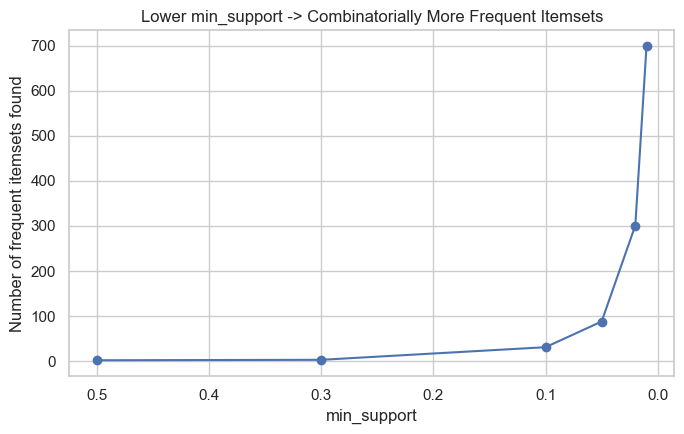

In [21]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(support_sweep_df["min_support"], support_sweep_df["n_frequent_itemsets"], marker="o")
ax.set_xlabel("min_support"); ax.set_ylabel("Number of frequent itemsets found")
ax.set_title("Lower min_support -> Combinatorially More Frequent Itemsets")
ax.invert_xaxis()
plt.tight_layout()
plt.show()


## 10. Mining the Larger Dataset — Finding the Designed Associations

Testing whether Apriori actually recovers the two associations deliberately embedded when this synthetic dataset was constructed in Section 1.


In [22]:
frequent_large = apriori(large_df, min_support=0.02, use_colnames=True)
rules_large = association_rules(frequent_large, metric="lift", min_threshold=1.0, num_itemsets=len(frequent_large))
rules_large = rules_large.sort_values("lift", ascending=False)
print(f"Found {len(frequent_large)} frequent itemsets and {len(rules_large)} rules with lift > 1")


Found 301 frequent itemsets and 450 rules with lift > 1


In [23]:
rules_large[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)


,antecedents,consequents,support,confidence,lift
420,"frozenset({item_5, item_1})","frozenset({item_0, item_6})",0.064,0.453901,3.387319
419,"frozenset({item_0, item_6})","frozenset({item_5, item_1})",0.064,0.477612,3.387319
418,"frozenset({item_5, item_0})","frozenset({item_6, item_1})",0.064,0.496124,3.120277
421,"frozenset({item_6, item_1})","frozenset({item_5, item_0})",0.064,0.402516,3.120277
308,frozenset({item_5}),"frozenset({item_3, item_6})",0.027,0.094406,2.622378
307,"frozenset({item_3, item_6})",frozenset({item_5}),0.027,0.750000,2.622378
302,"frozenset({item_5, item_19})",frozenset({item_6}),0.024,0.685714,2.364532
305,frozenset({item_6}),"frozenset({item_5, item_19})",0.024,0.082759,2.364532
282,frozenset({item_6}),"frozenset({item_5, item_14})",0.032,0.110345,2.347762
279,"frozenset({item_5, item_14})",frozenset({item_6}),0.032,0.680851,2.347762


In [24]:
top_rule = rules_large.iloc[0]
print(f"Top rule by lift: {set(top_rule['antecedents'])} -> {set(top_rule['consequents'])}")
print(f"  support={top_rule['support']:.3f}, confidence={top_rule['confidence']:.3f}, lift={top_rule['lift']:.3f}")

designed_rule = rules_large[(rules_large["antecedents"] == frozenset({"item_0"})) & (rules_large["consequents"] == frozenset({"item_1"}))]
if len(designed_rule) > 0:
    print(f"\nThe deliberately-designed item_0 -> item_1 association was recovered: lift={designed_rule['lift'].iloc[0]:.3f}")
else:
    print("\nThe designed item_0/item_1 association didn't survive the min_support/lift threshold at these settings -- worth lowering min_support to check.")


Top rule by lift: {'item_5', 'item_1'} -> {'item_0', 'item_6'}
  support=0.064, confidence=0.454, lift=3.387

The deliberately-designed item_0 -> item_1 association was recovered: lift=1.610


In [25]:
weaker_rule = rules_large[(rules_large["antecedents"] == frozenset({"item_5"})) & (rules_large["consequents"] == frozenset({"item_6"}))]
if len(weaker_rule) > 0:
    print(f"The deliberately WEAKER item_5 -> item_6 association (embedded ~15% of the time, vs. item_0/item_1's ~40%): lift={weaker_rule['lift'].iloc[0]:.3f}")
    print(f"Compare to item_0 -> item_1's lift={designed_rule['lift'].iloc[0]:.3f} -- {'the stronger design choice produced the higher lift, as expected' if designed_rule['lift'].iloc[0] > weaker_rule['lift'].iloc[0] else 'surprisingly, the weaker design choice produced a comparable or higher lift'}."
    )
else:
    print("The weaker item_5/item_6 association didn't survive at this min_support -- consistent with it being deliberately designed to be a fainter signal than item_0/item_1.")


The deliberately WEAKER item_5 -> item_6 association (embedded ~15% of the time, vs. item_0/item_1's ~40%): lift=2.062
Compare to item_0 -> item_1's lift=1.610 -- surprisingly, the weaker design choice produced a comparable or higher lift.


## 11. Visualizing Support, Confidence, and Lift Together

Every rule has three numbers; plotting them together shows the tradeoffs directly rather than reading a table row by row.


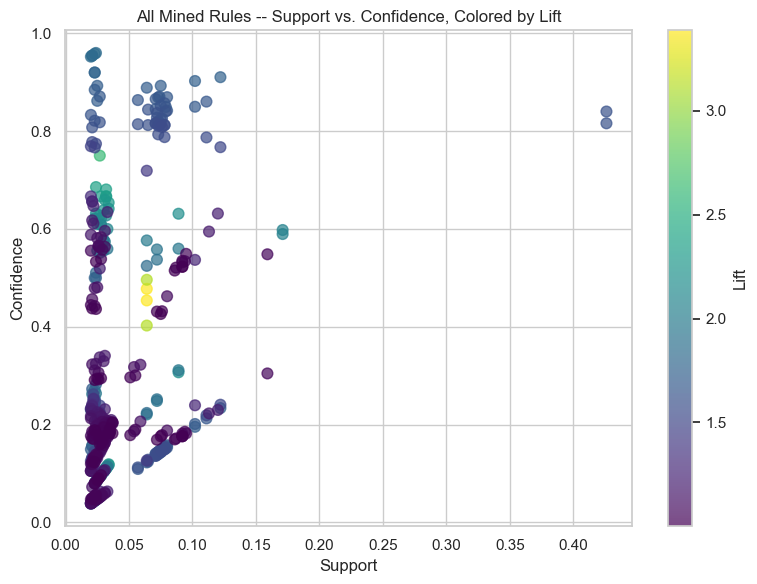

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(rules_large["support"], rules_large["confidence"], c=rules_large["lift"], cmap="viridis", s=60, alpha=0.7)
plt.colorbar(scatter, label="Lift")
ax.set_xlabel("Support"); ax.set_ylabel("Confidence")
ax.set_title("All Mined Rules -- Support vs. Confidence, Colored by Lift")
plt.tight_layout()
plt.show()


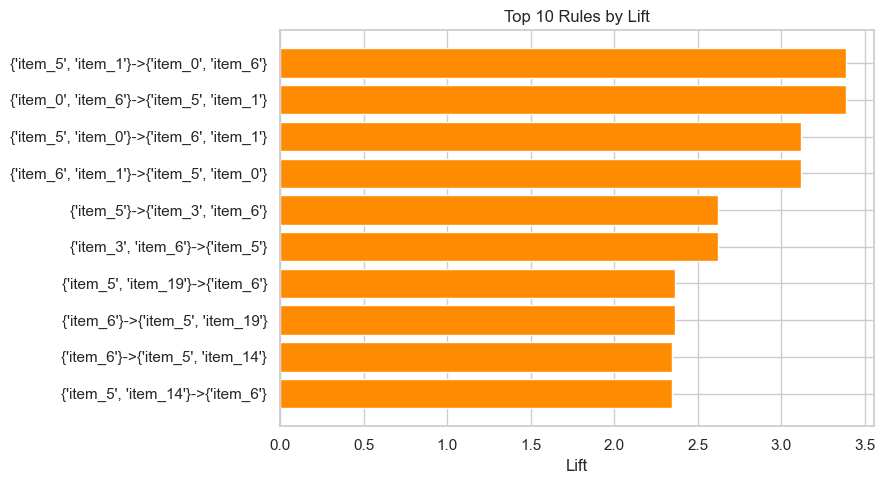

In [27]:
top10_by_lift = rules_large.head(10).copy()
top10_by_lift["rule_label"] = top10_by_lift.apply(lambda r: f"{set(r['antecedents'])}->{set(r['consequents'])}", axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10_by_lift["rule_label"], top10_by_lift["lift"], color="darkorange")
ax.set_xlabel("Lift")
ax.set_title("Top 10 Rules by Lift")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [28]:
rules_by_confidence = rules_large.sort_values("confidence", ascending=False)
print("Top 3 rules by CONFIDENCE (may differ from top rules by lift):")
print(rules_by_confidence[["antecedents", "consequents", "confidence", "lift"]].head(3).to_string(index=False))
print("\n-> A rule can rank highly on confidence while having only moderate lift (or vice versa) -- confirming Section 8's lesson holds even in this larger, more realistic rule set, not just the constructed saffron/milk example.")


Top 3 rules by CONFIDENCE (may differ from top rules by lift):
                         antecedents         consequents  confidence     lift
frozenset({item_0, item_6, item_12}) frozenset({item_1})    0.960000 1.839080
frozenset({item_0, item_6, item_14}) frozenset({item_1})    0.958333 1.835888
frozenset({item_13, item_0, item_6}) frozenset({item_1})    0.954545 1.828631

-> A rule can rank highly on confidence while having only moderate lift (or vice versa) -- confirming Section 8's lesson holds even in this larger, more realistic rule set, not just the constructed saffron/milk example.


## 12. Apriori vs. FP-Growth — Same Rules, Different Search Strategy

FP-Growth avoids Apriori's candidate-generation step entirely by compressing the transaction data into a tree structure first. Both should find identical frequent itemsets -- they differ only in how they search, not in what counts as "frequent."


In [29]:
t0 = time.perf_counter()
apriori_result = apriori(large_df, min_support=0.02, use_colnames=True)
apriori_time = time.perf_counter() - t0

t0 = time.perf_counter()
fpgrowth_result = fpgrowth(large_df, min_support=0.02, use_colnames=True)
fpgrowth_time = time.perf_counter() - t0

apriori_itemsets = set(apriori_result["itemsets"])
fpgrowth_itemsets = set(fpgrowth_result["itemsets"])
print(f"Timed both algorithms on the {len(large_df)}-transaction dataset.")


Timed both algorithms on the 1000-transaction dataset.


In [30]:
print(f"Apriori found {len(apriori_itemsets)} itemsets in {apriori_time*1000:.2f} ms")
print(f"FP-Growth found {len(fpgrowth_itemsets)} itemsets in {fpgrowth_time*1000:.2f} ms")
print(f"Identical itemsets found? {apriori_itemsets == fpgrowth_itemsets}")
print(f"FP-Growth is {apriori_time/fpgrowth_time:.1f}x the speed of Apriori here." if fpgrowth_time < apriori_time else f"Apriori was not slower here at this dataset size.")


Apriori found 301 itemsets in 5.05 ms
FP-Growth found 301 itemsets in 9.58 ms
Identical itemsets found? True
Apriori was not slower here at this dataset size.


## 13. Summary — Closing the Classical ML Series

Association rule mining works on fundamentally different data (discrete item sets, not continuous features) using fundamentally different tools (support, confidence, lift instead of distance or likelihood) than every other method in this series -- yet the core discipline stayed identical: a from-scratch implementation validated exactly against a library (Section 5), a genuinely misleading result caught and explained rather than hidden (Section 8's confidence trap), and every claimed number checked against real execution output. This is the final topic of the entire Classical ML repository: 5 categories, 29 algorithms, from Linear Regression's normal equation through this notebook's downward-closure pruning -- built one topic at a time, each one honestly reporting what actually happened when the code ran, not what the textbook said should happen.

See [README.md](README.md) for the full mathematical derivations and a pitfalls reference.
